In [44]:
import pyrpl
from pyrpl import Pyrpl
from moku.instruments import WaveformGenerator
from moku.instruments import Oscilloscope
from moku.instruments import MultiInstrument
from time import sleep
import numpy as np
import matplotlib.pyplot as plt
import types
import matplotlib
import scipy
import json

from calibration import Calibrator

plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.constrained_layout.use'] = True
%config InlineBackend.figure_format = 'retina'


In [45]:
HOSTNAME = 'qifo-pitaya-1.local'
#HOSTNAME = '192.168.0.181'
PASSWORD = "L!g0bears"

MOKU_IP = "192.168.0.26"

p = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
rp = p.rp

try:
    
    mim = MultiInstrument(MOKU_IP, platform_id=2, force_connect = True)
    print(f"Connected to Moku:Go at {MOKU_IP}")

except:
    print("Error connecting to Moku! possible already connected")

INFO:pyrpl.redpitaya:Correct FPGA image detected, skipping reload
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname qifo-pitaya-1.local.


Connected to Moku:Go at 192.168.0.26


In [46]:
scope_decimation = 256
scope_sample_freq = 1 / (8 * 10**-9 * 2**14 * scope_decimation)
scope_trace_times = np.linspace(start = 0, stop = 1 / scope_sample_freq, num = 2**14)

asg0 = rp.asg0
scope = rp.scope

moku_wg = mim.set_instrument(1, WaveformGenerator)
moku_scope = mim.set_instrument(2, Oscilloscope)


In [47]:
#calibrate = Calibrator("pitaya2_calibration.json")

In [48]:
connections = [dict(source="Slot1OutA", destination="Output1"),
               dict(source="Input1", destination="Slot2InA"),
               dict(source="Input2", destination="Slot2InB")]

mim.set_connections(connections)

[{'destination': 'Slot1InA', 'source': 'Slot2OutA'},
 {'destination': 'Slot2InA', 'source': 'Input1'},
 {'destination': 'Slot2InB', 'source': 'Input2'},
 {'destination': 'Output1', 'source': 'Slot1OutA'}]

In [49]:
def sine(x, A, f, phi, B):
    return np.abs(A) * np.sin(2 * np.pi * f * x + phi) + B

def take_immediate_scope_trace(decimation: int = 256, input1:str="in1", input2:str="in2") -> list:
    scope.decimation = decimation

    scope.input1 = input1
    scope.input2 = input2

    scope.threshold = 0
    scope.hysteresis = 0.01

    scope.trigger_source = 'immediately'
    scope.trigger_delay = 0

    return scope.single()

In [50]:
def calibrate_input(pitaya_input: int):
    if(pitaya_input != 1 and pitaya_input != 2):
         print("Improper pitaya input! setting to in1")
         pitaya_input = 1

    if(pitaya_input == 1): 
        mim.set_connections([dict(source="Slot1OutA", destination="Output1")])
    elif(pitaya_input == 2):
        mim.set_connections([dict(source="Slot1OutA", destination="Output2")])

    moku_waveform_params = types.SimpleNamespace(
        amplitude = 1,
        frequency = 2 * scope_sample_freq,
        offset = 0
    )
    moku_wg.generate_waveform(channel=1, type = 'Sine', amplitude=moku_waveform_params.amplitude*2, frequency=moku_waveform_params.frequency, offset=moku_waveform_params.offset, dc_level=0.0)

    ch1, ch2 = take_immediate_scope_trace(decimation=scope_decimation)
    if(pitaya_input == 1): 
        trace = ch1
    elif(pitaya_input == 2):
        trace = ch2
    else:
        trace = np.zeros(2*14)


    popt, __ = scipy.optimize.curve_fit(sine, scope_trace_times, trace, p0=[1, 2*scope_sample_freq, 0, 0])
    A = popt[0]
    f = popt[1]
    phi = popt[2]
    B = popt[3]

    # plt.plot(scope_trace_times, trace, color='blue', alpha = 1, linewidth = 2)
    # plt.plot(scope_trace_times, sine(scope_trace_times, A, f, phi, B), color='red', alpha = 1, linewidth = 1)

    # plt.plot(scope_trace_times, calibrate.correct_input(pitaya_input, trace), color='green', alpha = 1, linewidth = 1)

    calibrated_params = dict(gain = moku_waveform_params.amplitude / np.abs(A), offset = moku_waveform_params.offset - B)
    return calibrated_params



def calibrate_output(pitaya_output: int):
    if(pitaya_output != 1 and pitaya_output != 2):
            print("Improper pitaya input! setting to in1")
            pitaya_output = 1
    
    if(pitaya_output == 1): 
        mim.set_connections([dict(source="Input1", destination="Slot2InA")])
    elif(pitaya_output == 2):
        mim.set_connections([dict(source="Input2", destination="Slot2InA")])

    pitaya_waveform_params = types.SimpleNamespace(
        amplitude = 1,
        frequency = 2 * scope_sample_freq,
        offset = 0
    )

    asg0.setup(waveform="sin",output_direct=f"out{pitaya_output}",trigger_source='immediately',frequency=pitaya_waveform_params.frequency,amplitude=pitaya_waveform_params.amplitude,offset=pitaya_waveform_params.offset)

    moku_scope_sample_time = 2 / pitaya_waveform_params.frequency
    moku_scope_sample_points = 16384

    moku_scope.set_timebase(t1=0, t2 = moku_scope_sample_time, max_length = moku_scope_sample_points)
    moku_scope.set_acquisition_mode("Precision")

    data = moku_scope.get_data()
    times = np.asarray(data["time"])
    ch1 = np.asarray(data["ch1"])

    popt, __ = scipy.optimize.curve_fit(sine, data["time"], data["ch1"], p0=[1, pitaya_waveform_params.frequency, 0, 0])
    A = popt[0]
    f = popt[1]
    phi = popt[2]
    B = popt[3]

    plt.grid(True)
    plt.plot(times, ch1, color='blue', alpha = 1, linewidth = 2)
    plt.plot(times, sine(times, A, f, phi, B), color='red', alpha = 1, linewidth = 1)

    #plt.plot(times, calibrate.correct_output(pitaya_output, ch1), color='green', alpha = 1, linewidth = 1)

    calibrated_params = dict(gain = pitaya_waveform_params.amplitude / np.abs(A), offset = pitaya_waveform_params.offset - B)
    return calibrated_params




In [51]:
def calibrate_to_file(filename: str = "calibration.json"):
    input1_calibration = calibrate_input(pitaya_input = 1)
    input2_calibration = calibrate_input(pitaya_input = 2)

    output1_calibration = calibrate_output(pitaya_output = 1)
    output2_calibration = calibrate_output(pitaya_output = 2)

    configs = dict(name=HOSTNAME, input1=input1_calibration, input2=input2_calibration, output1=output1_calibration, output2=output2_calibration)

    with open(filename, "w") as config_file:
        json.dump(configs, config_file, indent=4)

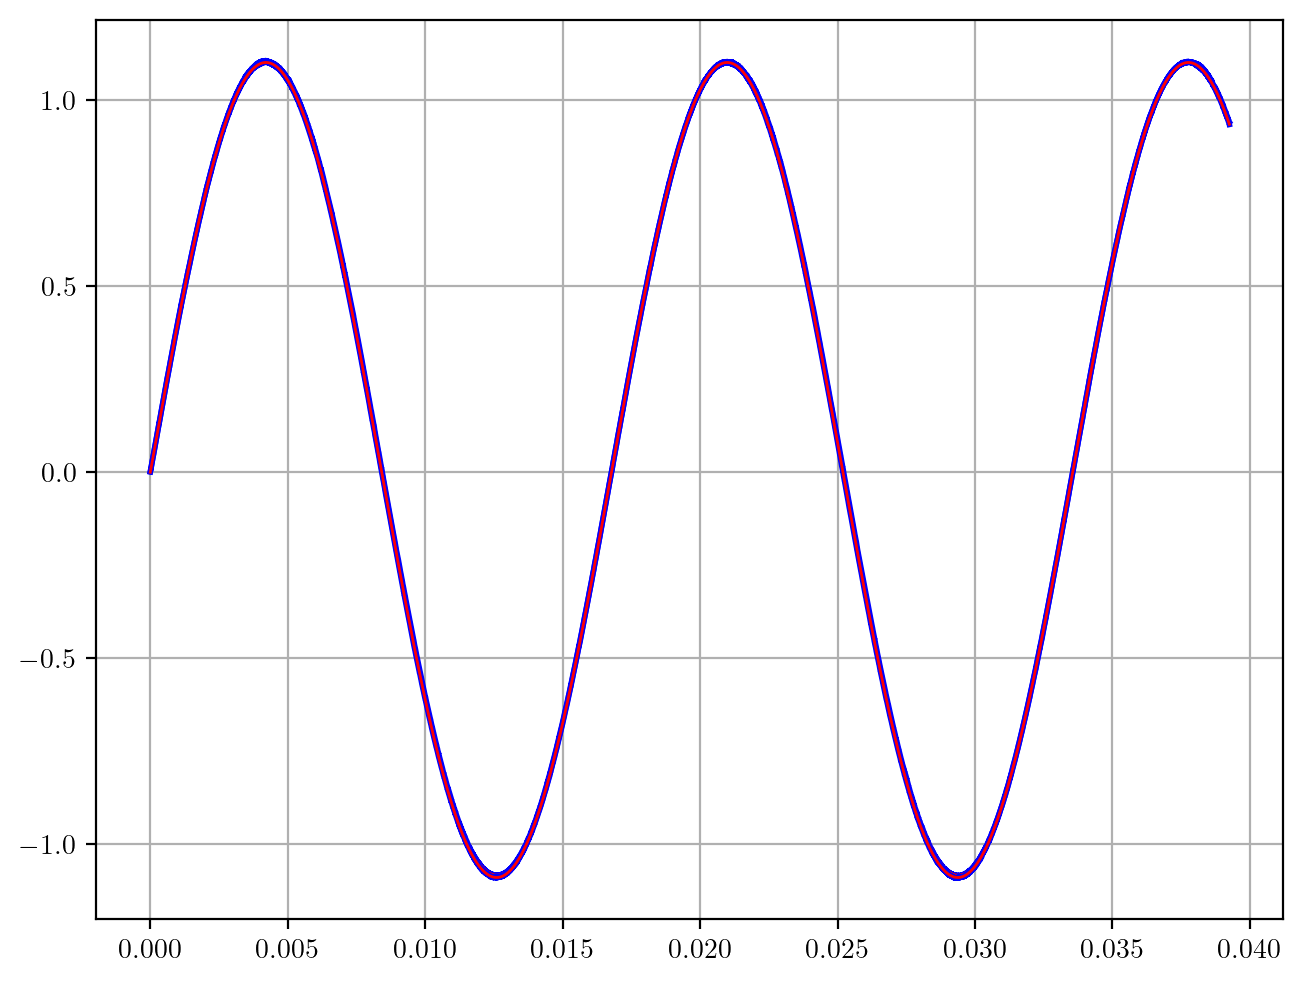

In [52]:
calibrate_to_file("pitaya1_calibration.json")